In [ ]:
import torch
import torch.nn.functional as F
import torch.nn as nn
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt

In [ ]:
## input: shape [batch_size, 1, 28, 28]
## output: [batchsize, 10]
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

transform = transforms.ToTensor()

mnist_dataset = datasets.MNIST(
    root="./data",
    train=True,
    download=True,
    transform=transform,
)

In [3]:
loader = DataLoader(
    mnist_dataset,
    batch_size=2,
    shuffle=True,
)
linear_img_model = nn.Linear(28*28, 10)

In [4]:
### linear model

linear_img_model = nn.Linear(28*28, 10)
linear_img_model.to(device)

correct = 0
total = 0
with torch.no_grad():
    for images, labels in loader:
        
        flat_images = images.view(images.size(0), -1)
        output = linear_img_model(flat_images)
        preds = output.argmax(dim = 1)
        
        correct += (preds == labels).sum().item()
        total += labels.size(0)

accuracy = correct/total

print("accuracy:", accuracy)
print(f"liczba parametrow: {sum(p.numel() for p in linear_img_model.parameters())}")


accuracy: 0.07666666666666666
liczba parametrow: 7850


In [5]:
##cnn

class SimpleCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(1, 8, kernel_size=3)
        self.conv2 = nn.Conv2d(8, 16, kernel_size=3)

        self.fc1 = nn.Linear(16 * 24 * 24, 128)
        self.fc2 = nn.Linear(128, 10)
    def forward(self, x):
        x = F.relu(self.conv1(x))
        x = F.relu(self.conv2(x))

        x = torch.flatten(x, 1)

        x = F.relu(self.fc1(x))
        x = self.fc2(x)

        return x


In [6]:
cnn_model = SimpleCNN()
cnn_model.to(device)

correct = 0
total = 0

with torch.no_grad():
    for images, labels in loader:
        outputs = cnn_model(images)
        preds = outputs.argmax(dim=1)
        correct += (preds == labels).sum().item()
        total +=labels.size(0)

accuracy = correct / total
print(f"accuracy: {accuracy:.4f}")
print(f"liczba parametrow: {sum(p.numel() for p in cnn_model.parameters())}")


accuracy: 0.1024
liczba parametrow: 1182314


In [7]:
## CNN, even-odd 
##cnn

class CNN_even_odd(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(1, 8, kernel_size=3)
        self.conv2 = nn.Conv2d(8, 16, kernel_size=3)

        self.fc1 = nn.Linear(16 * 24 * 24, 128)
        self.fc2 = nn.Linear(128, 2)
    def forward(self, x):
        x = F.relu(self.conv1(x))
        x = F.relu(self.conv2(x))

        x = torch.flatten(x, 1)

        x = F.relu(self.fc1(x))
        x = self.fc2(x)

        return x


In [8]:
cnn_even_odd = CNN_even_odd()

correct = 0
total = 0

with torch.no_grad():
    for images, labels in loader:
        outputs = cnn_even_odd(images)
        preds = outputs.argmax(dim=1)
        labels = labels % 2
        correct += (preds == labels).sum().item()
        total +=labels.size(0)

accuracy = correct / total
print(f"accuracy: {accuracy:.4f}")
print(f"liczba parametrow: {sum(p.numel() for p in cnn_model.parameters())}")

accuracy: 0.4915
liczba parametrow: 1182314


In [9]:
class SimpleAutoencoder(nn.Module):
    def __init__(self, *args, **kwargs):
        super().__init__(*args, **kwargs)
        self.enc1 = nn.Conv2d(1, 8, 3, 2, 1)

        self.dec1 = nn.ConvTranspose2d(8, 1, 3, 2, 1, 1)
    def forward(self, x):
        x = F.relu(self.enc1(x))
        x = torch.sigmoid(self.dec1(x))
        return x

input shape:  torch.Size([2, 1, 28, 28])
output shape:  torch.Size([2, 1, 28, 28])
liczba parametrow: 153


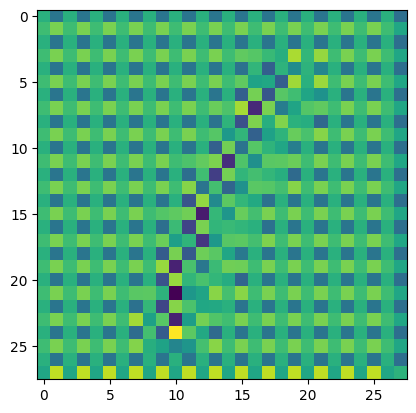

In [10]:
autoencoder = SimpleAutoencoder()
autoencoder.to(device)

images, labels = next(iter(loader))
images = images.to(device)
with torch.no_grad():
    output_images = autoencoder(images)

print("input shape: ", images.shape)
print("output shape: ", output_images.shape)
print(f"liczba parametrow: {sum(p.numel() for p in autoencoder.parameters())}")
plt.imshow(output_images[0, 0].detach().cpu())

In [11]:
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(autoencoder.parameters(), lr=0.001)

blad przypadajacy na 1 / 3 wynosi: 0.0004


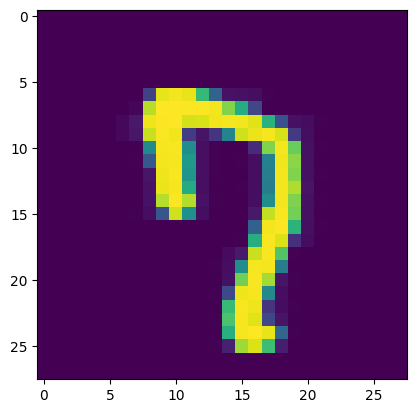

blad przypadajacy na 2 / 3 wynosi: 0.0003


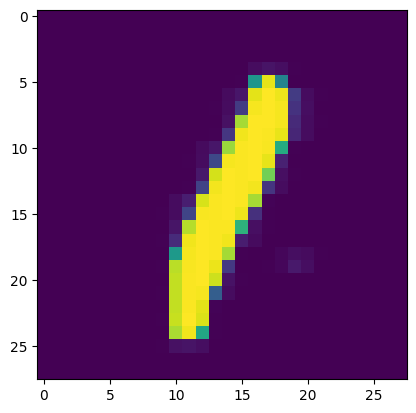

blad przypadajacy na 3 / 3 wynosi: 0.0004


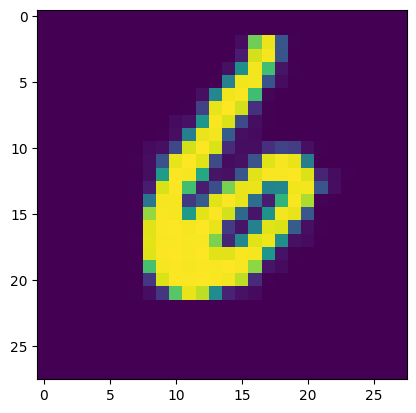

In [12]:
epochs = 3

for epoch in range(epochs):
    for images, _ in loader:
        images = images.to(device)
        ## czyszczenie gradientow
        optimizer.zero_grad()
        ## forward pass 
        output_images = autoencoder(images)
        ## loss
        loss = criterion(output_images, images)
        ## gradients calculation 
        loss.backward()
        ## actualization
        optimizer.step()
    print(f"blad przypadajacy na {epoch + 1} / {epochs} wynosi: {loss.item():.4f}")
    plt.imshow(output_images[0, 0].detach().cpu())
    plt.show()


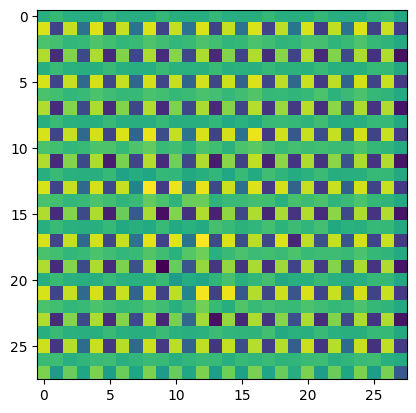

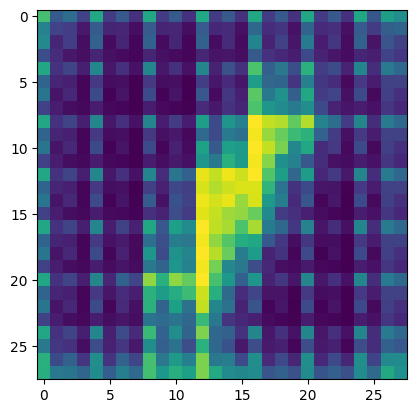

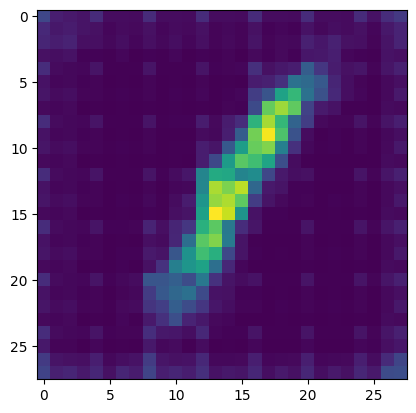

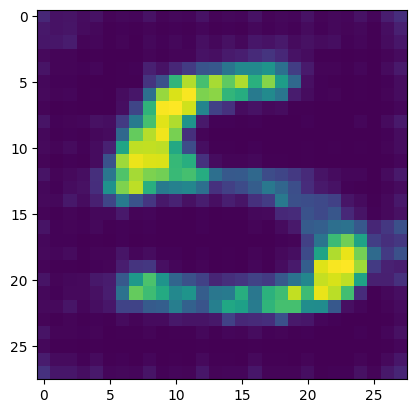

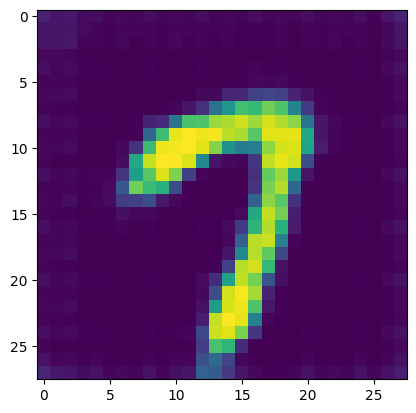

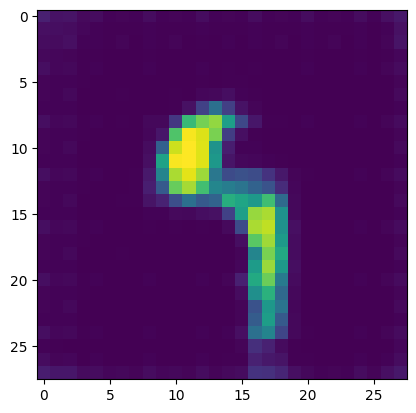

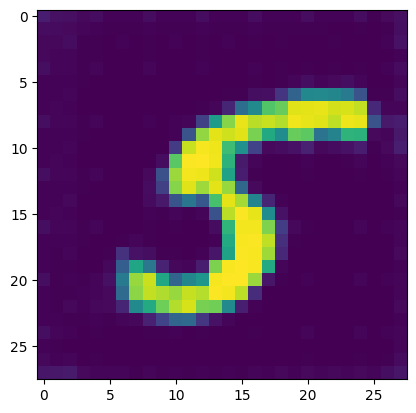

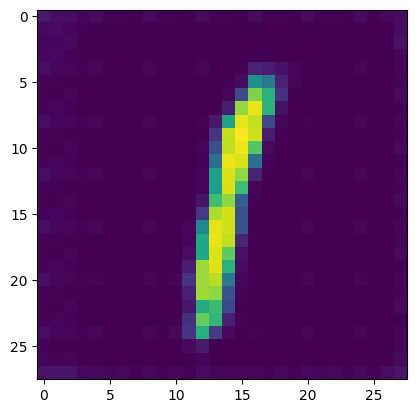

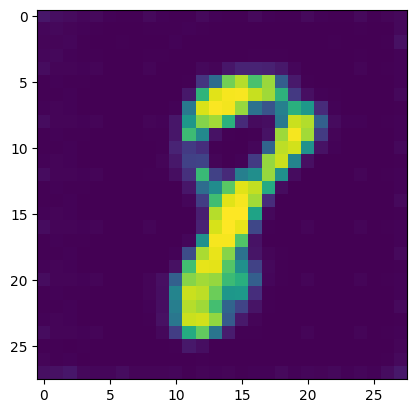

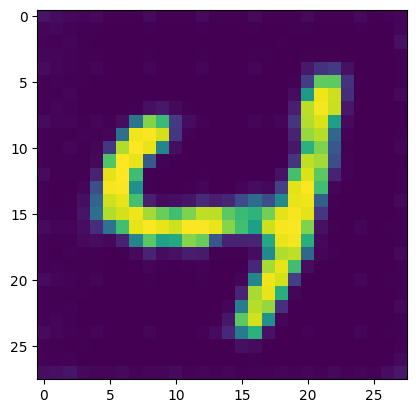

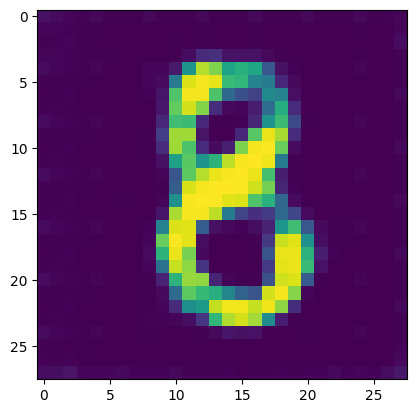

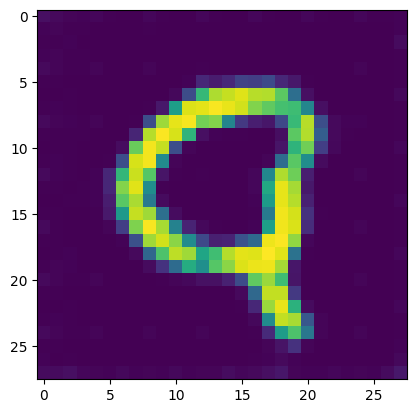

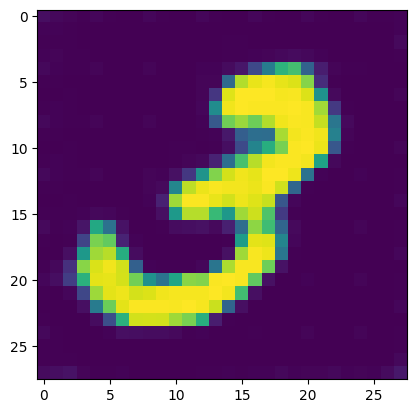

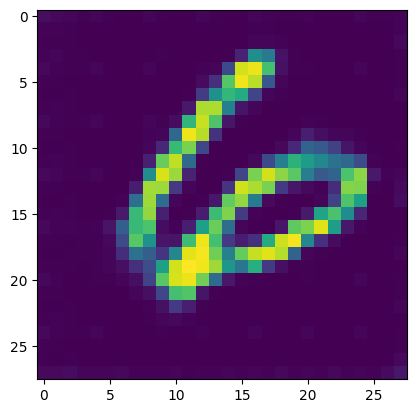

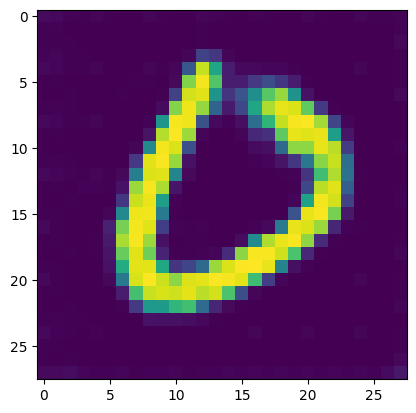

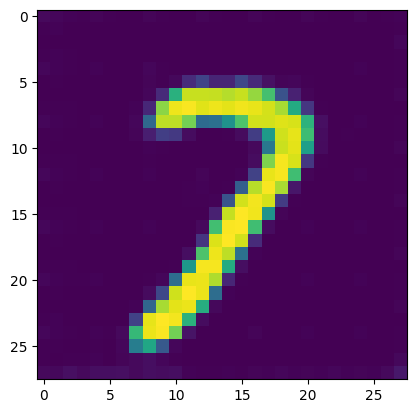

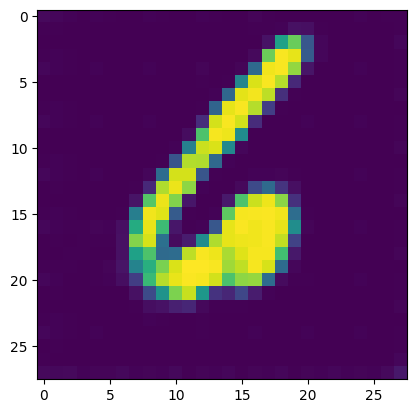

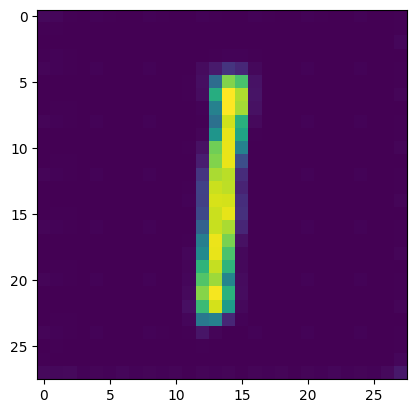

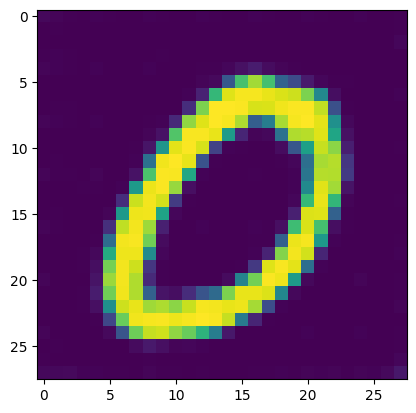

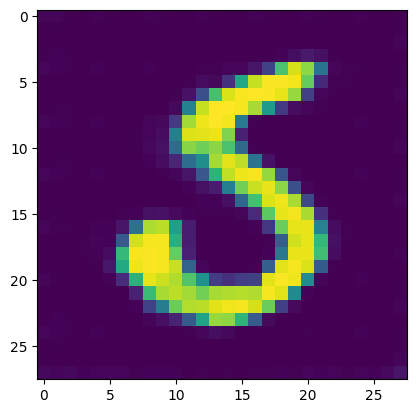

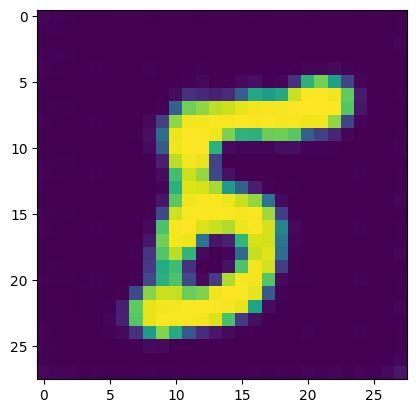

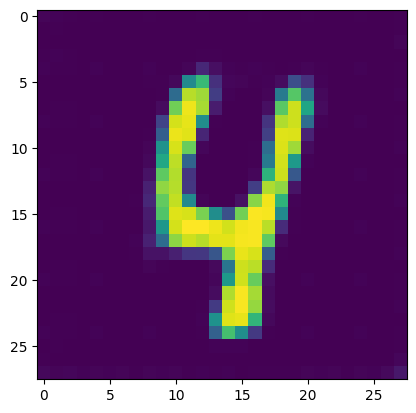

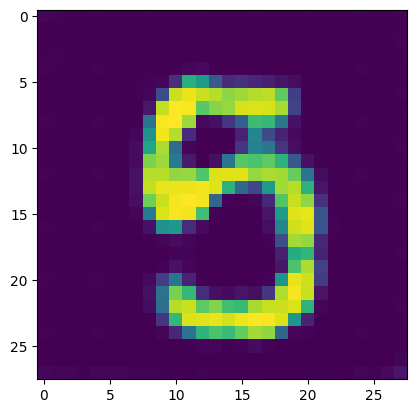

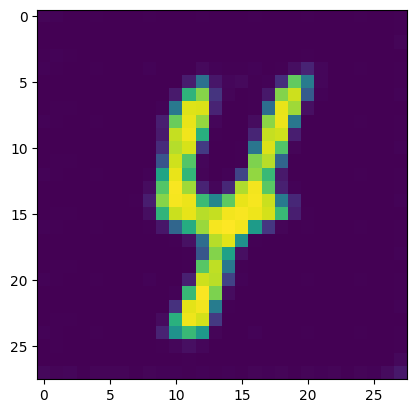

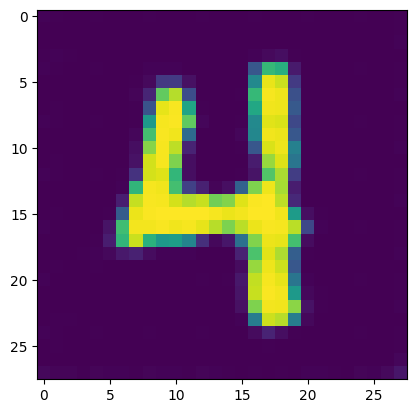

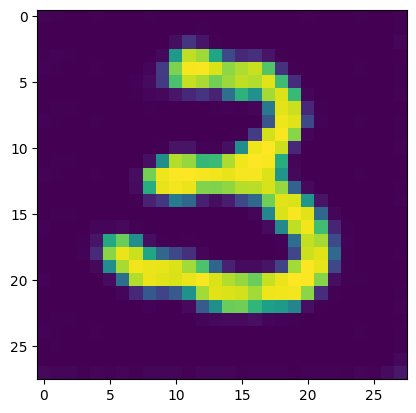

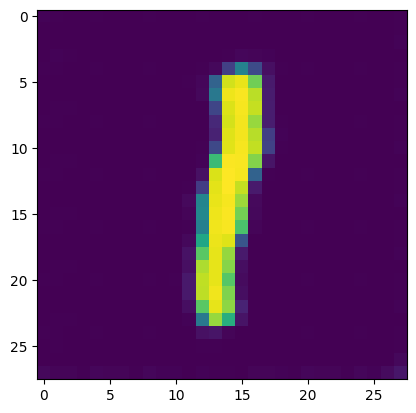

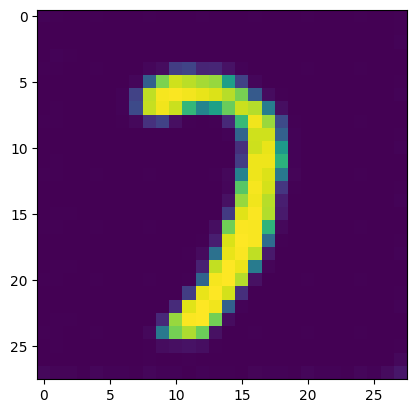

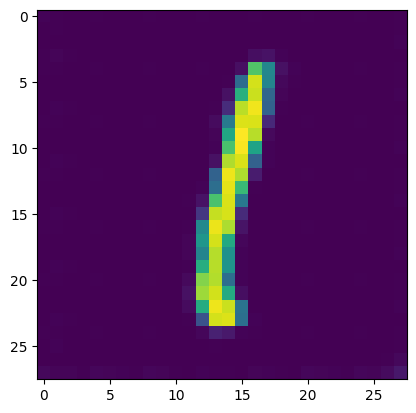

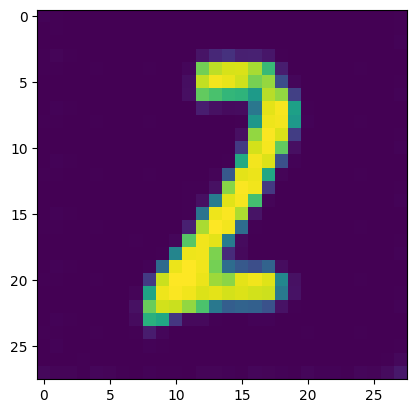

blad przypadajacy na 1 / 3 wynosi: 0.0076


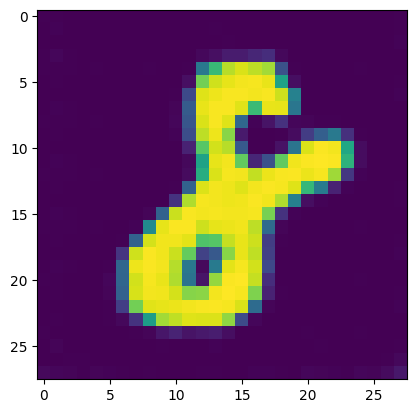

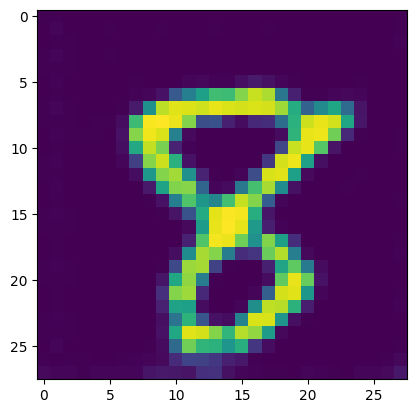

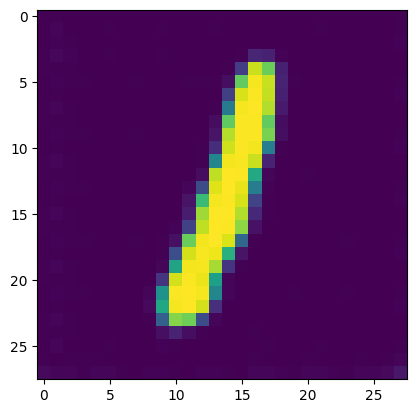

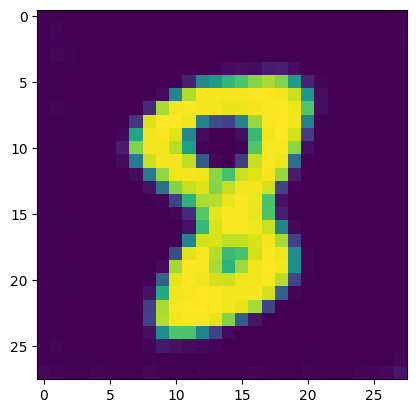

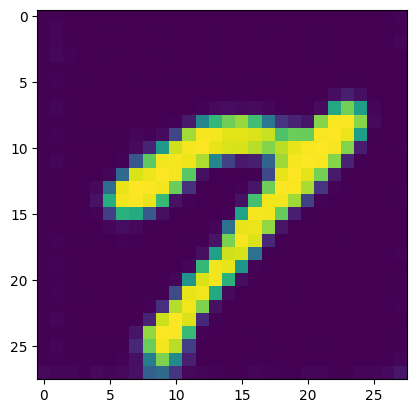

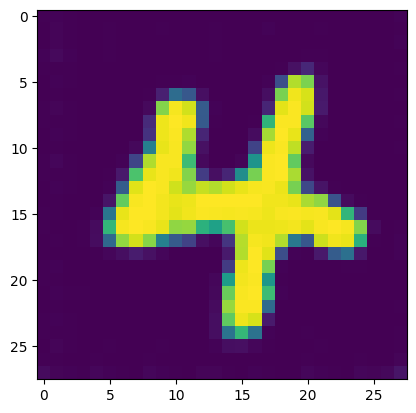

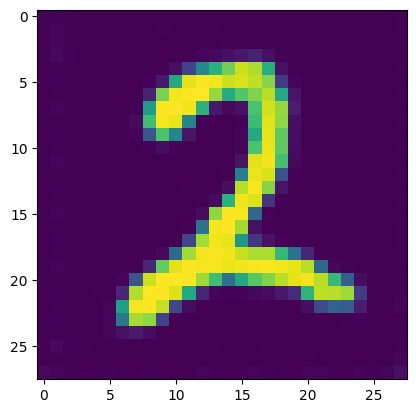

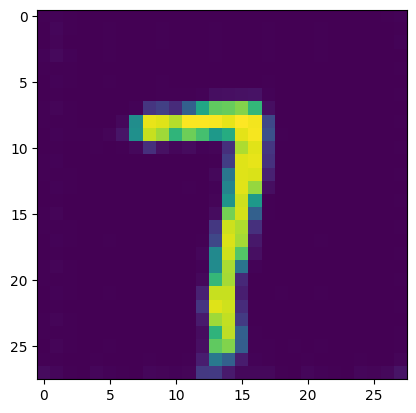

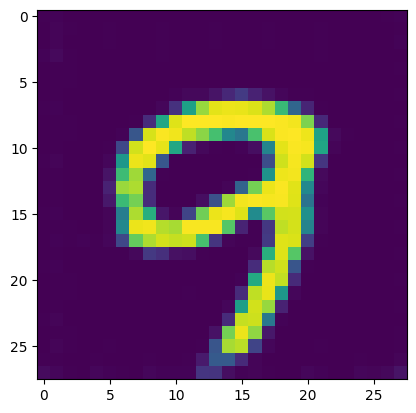

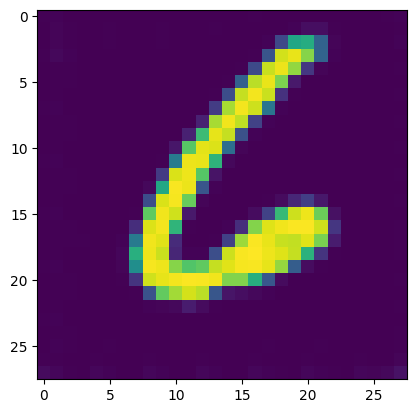

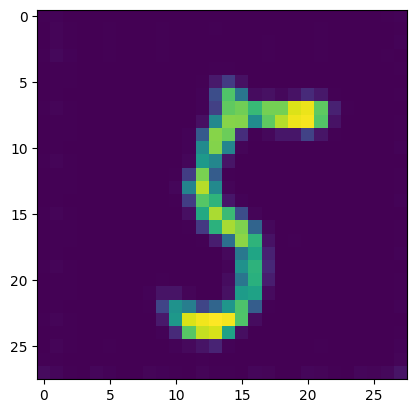

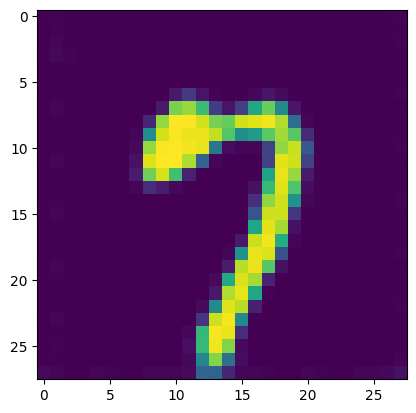

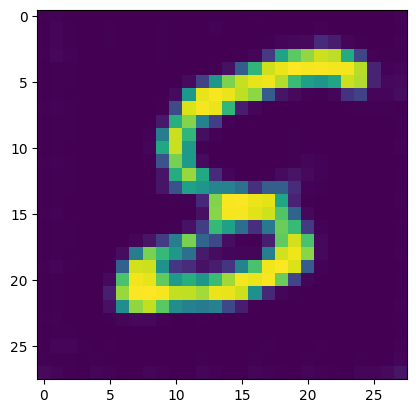

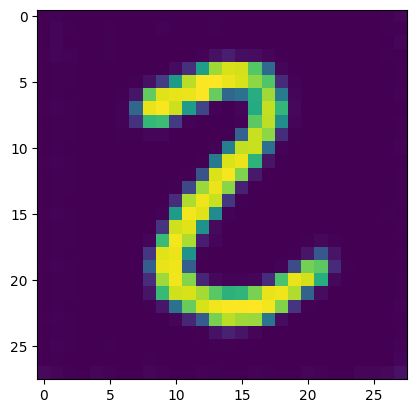

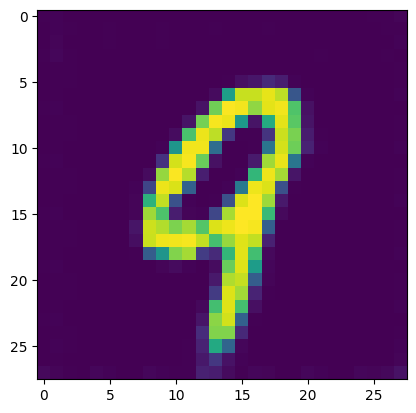

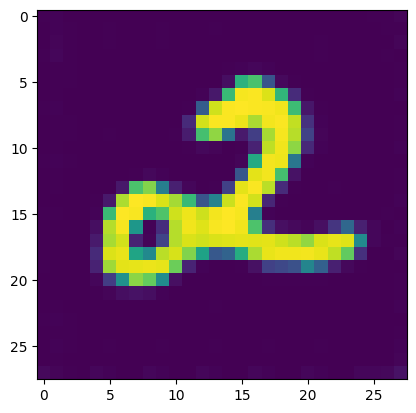

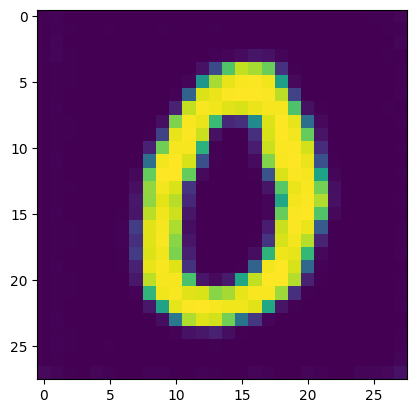

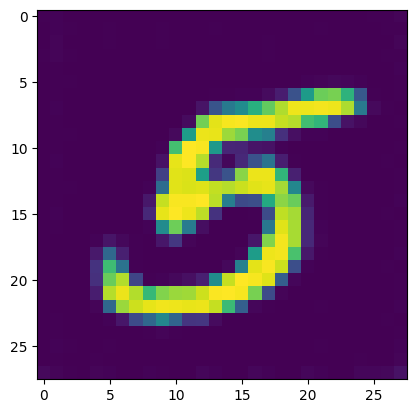

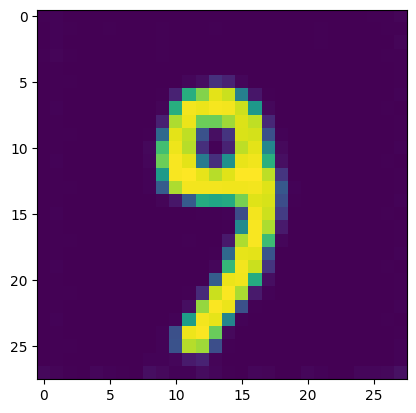

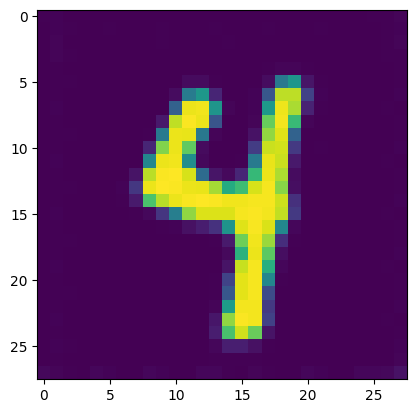

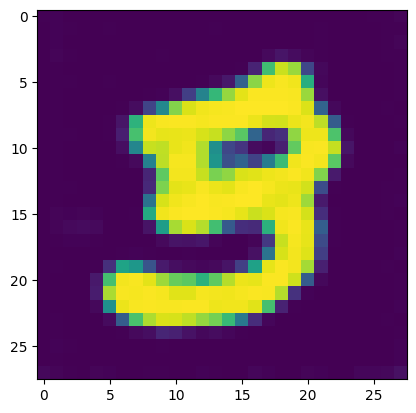

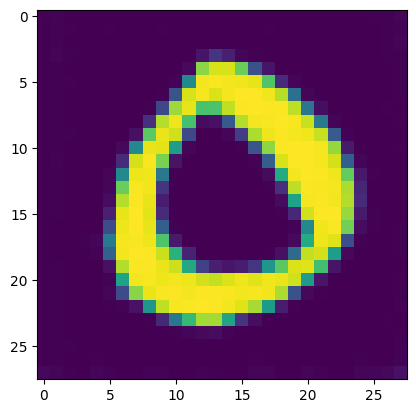

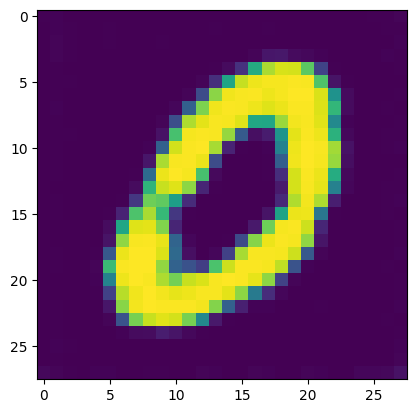

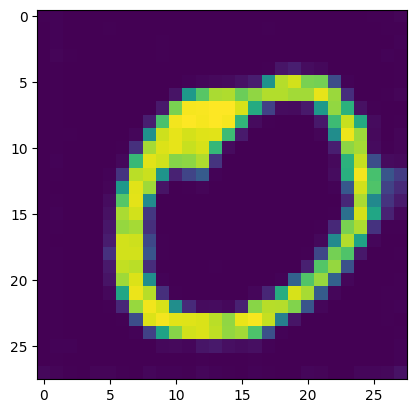

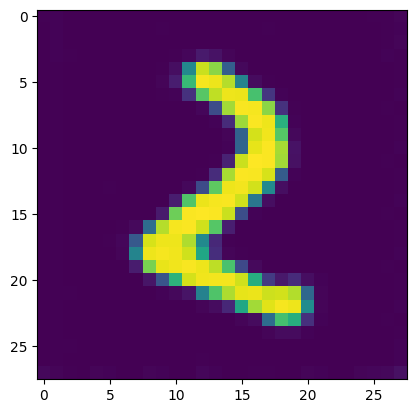

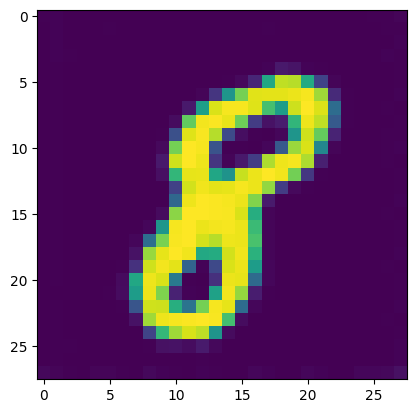

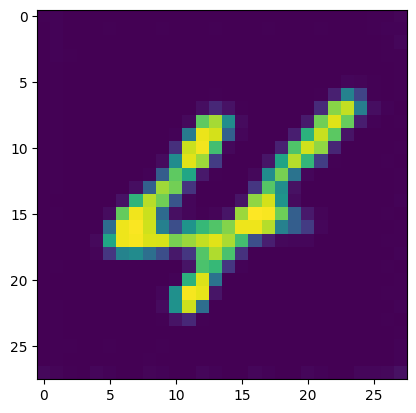

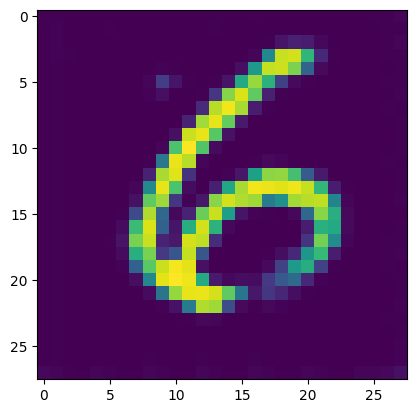

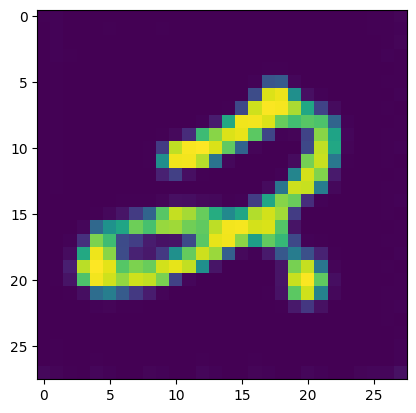

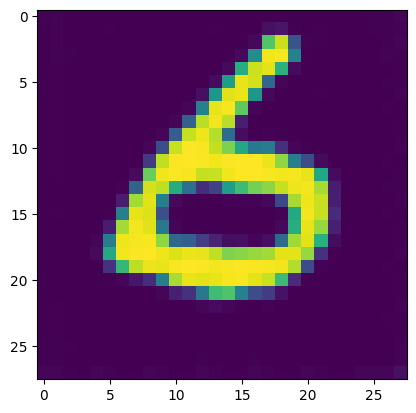

blad przypadajacy na 2 / 3 wynosi: 0.0008


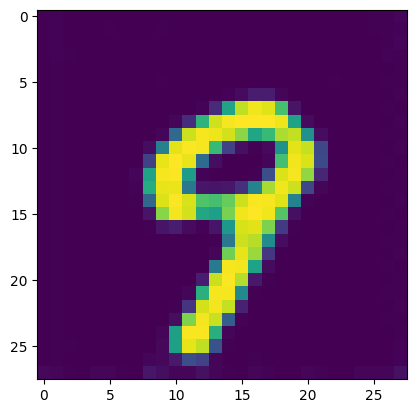

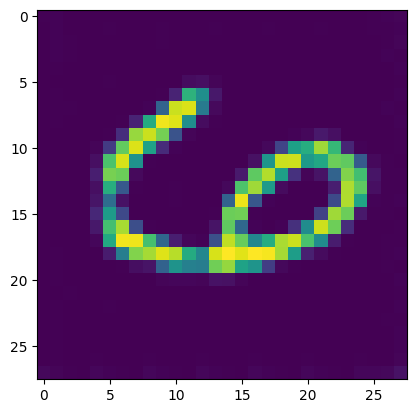

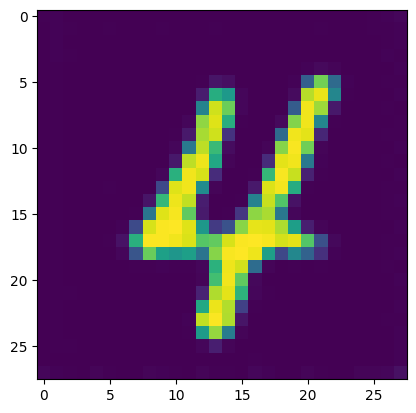

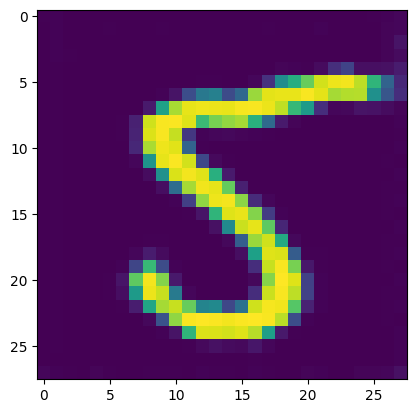

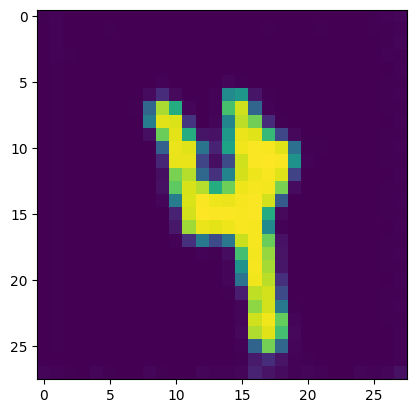

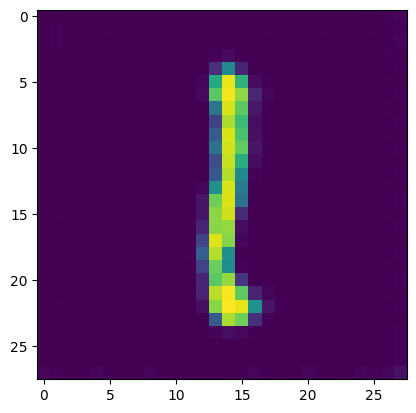

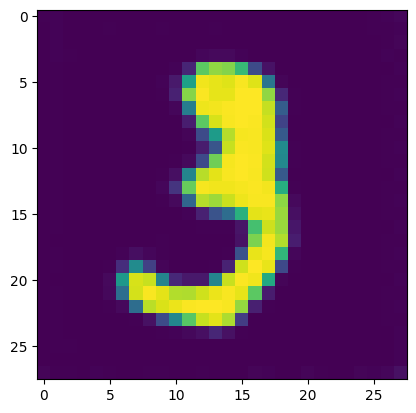

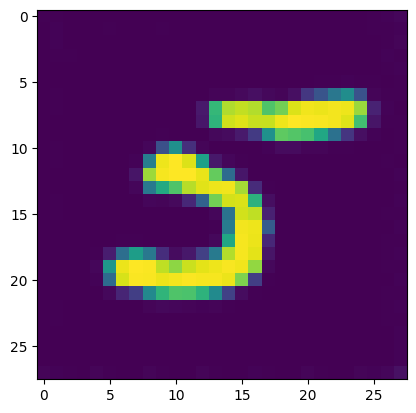

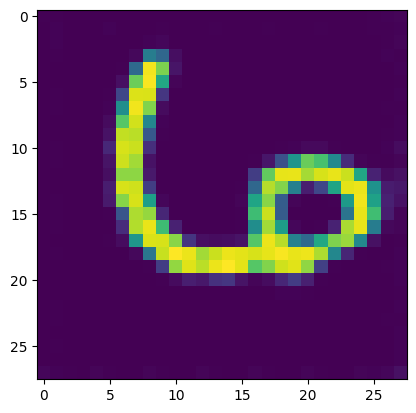

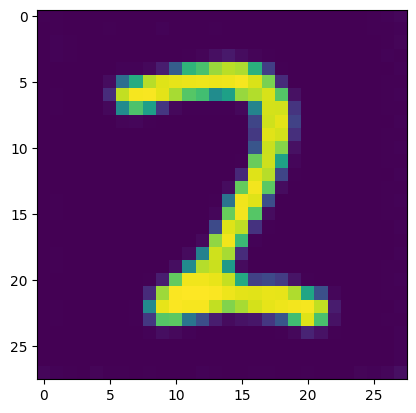

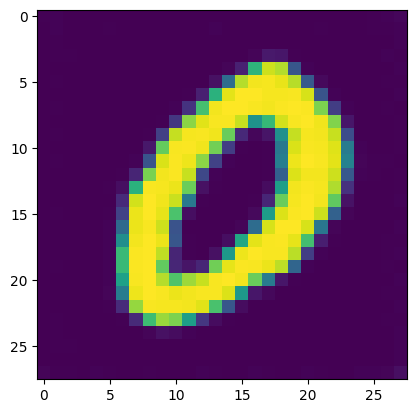

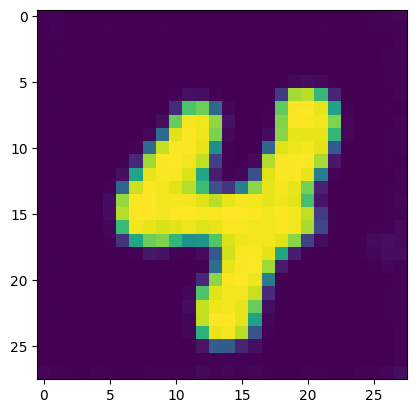

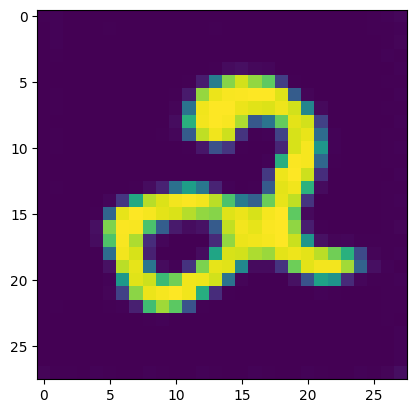

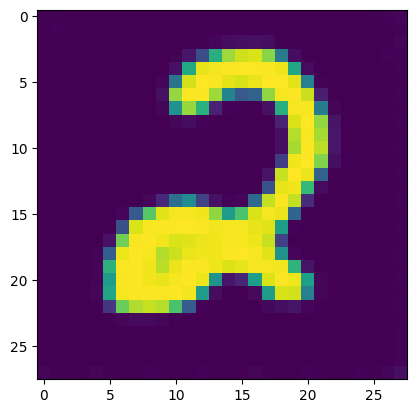

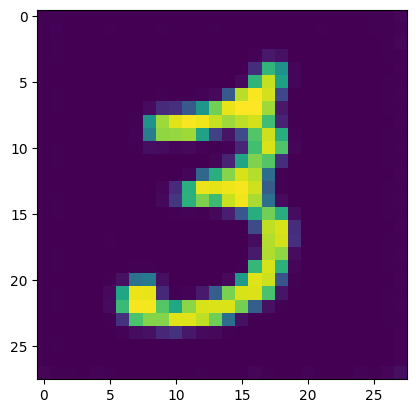

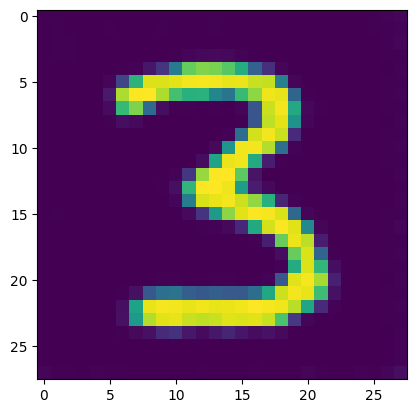

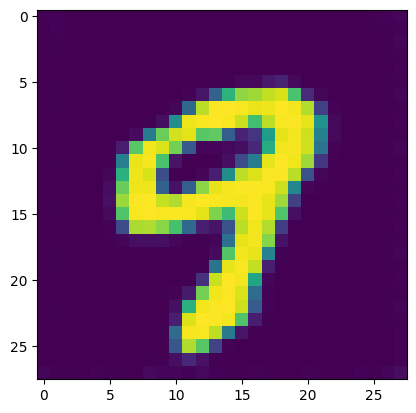

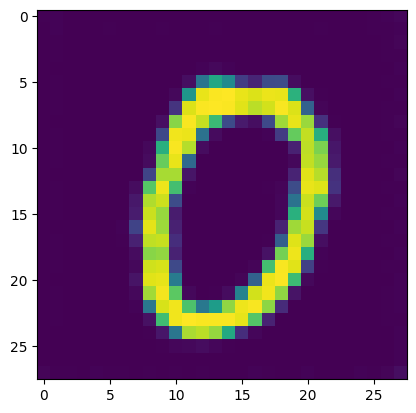

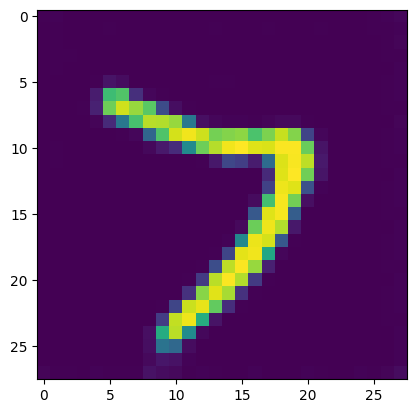

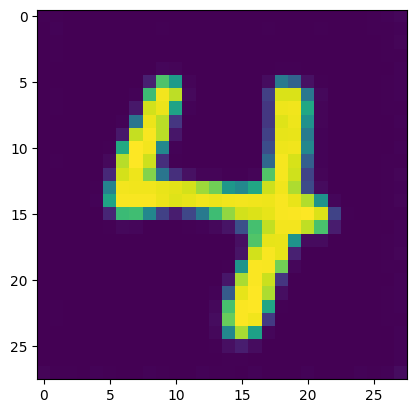

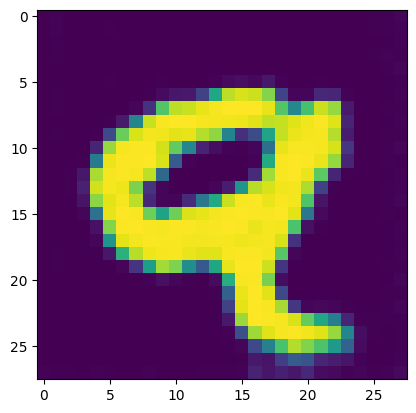

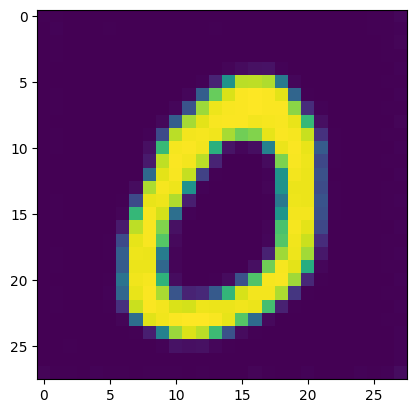

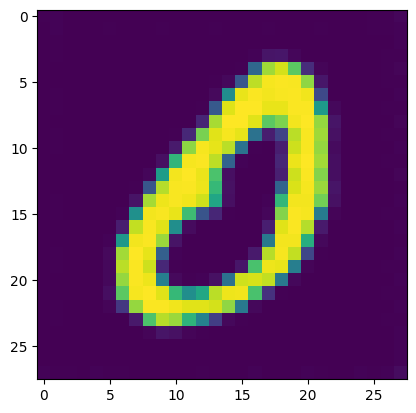

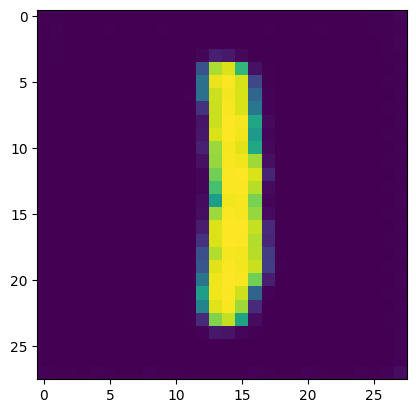

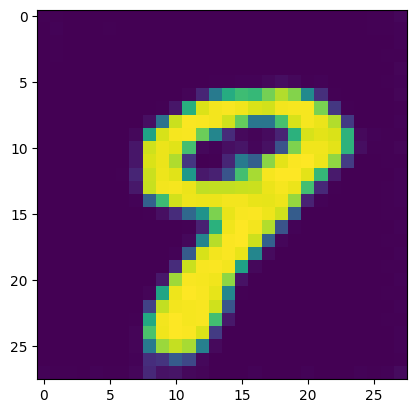

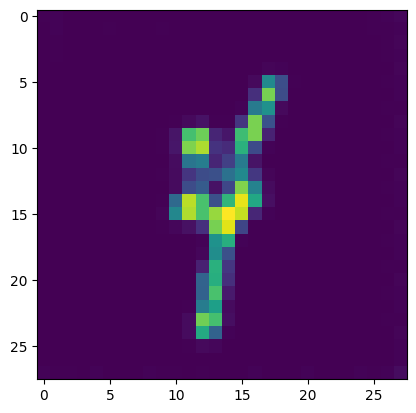

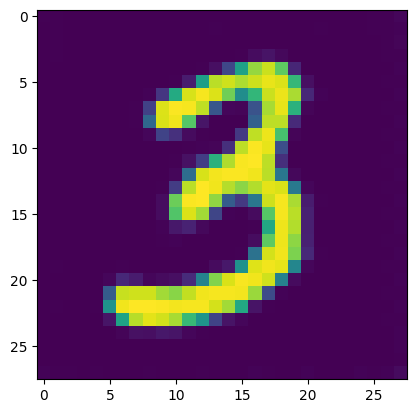

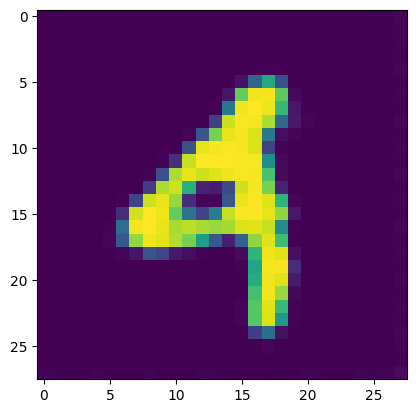

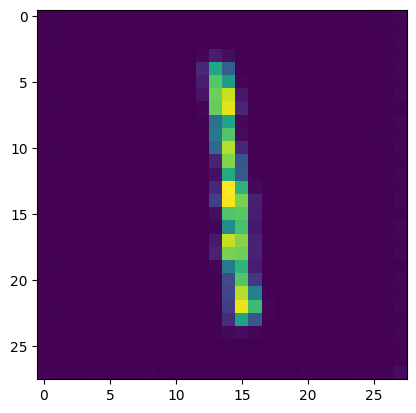

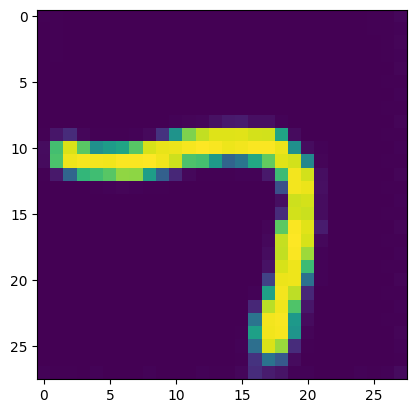

blad przypadajacy na 3 / 3 wynosi: 0.0022


In [ ]:
class SimpleAutoencoder(nn.Module):
    def __init__(self):
        super().__init__()

        self.enc1 = nn.Conv2d(1, 16, 3, 2, 1)
        self.enc2 = nn.Conv2d(16, 4, 3, 2, 1) 

        self.dec1 = nn.ConvTranspose2d(4, 16, 3, 2, 1, 1)
        self.dec2 = nn.ConvTranspose2d(16, 1, 3, 2, 1, 1)

    def forward(self, x):
        x = F.relu(self.enc1(x))
        x = F.relu(self.enc2(x))
        x = F.relu(self.dec1(x))
        x = torch.sigmoid(self.dec2(x))
        return x

autoencoder = SimpleAutoencoder().to(device)
optimizer = torch.optim.Adam(autoencoder.parameters(), lr=0.0001)

epochs = 3
i = 0

for epoch in range(epochs):
    for images, _ in loader:
        images = images.to(device)
        ## czyszczenie gradientow
        optimizer.zero_grad()
        ## forward pass 
        output_images = autoencoder(images)
        ## loss
        loss = criterion(output_images, images)
        ## gradients calculation 
        loss.backward()
        ## actualization
        optimizer.step()
        if i % 1000 == 0:
            plt.imshow(output_images[0, 0].detach().cpu())
            plt.show()
        i += 1
    print(f"blad przypadajacy na {epoch + 1} / {epochs} wynosi: {loss.item():.4f}")
